# Кластеризация сигналов сцинтилляционного детектора (v8 — эталон LB 0.89109)

**ФИО:** Анастасия Волконская  
**Группа:** М25-555

Ссылка на соревнование Kaggle:  
https://www.kaggle.com/competitions/signal-types-classification

**Цель:** три кластера импульсов сцинтиллятора. Финальная модель v8 — PSD `(L−S)/L` на окнах **offset=4, short=42**, порог `valley+0.003`, **асимметричный** class2: только низкий PSD (`q_lo=0.07`) → unknown. LB **0.89109**.

Перед работой я один раз сверила план с **консилиумом** (аналитик / физик / ML-инженер): критерий выбора — физика хвоста и LB, не silhouette.

❗Перед Run All положите `Run200_Wave_0_1.txt` в один из путей ниже (`data/`, `/content/data/`, …). В Colab можно загрузить файл через Files.

In [1]:
# @title Установка зависимостей
"""Проверка пакетов; в Colab при отсутствии — тихая установка через pip."""
import importlib
import subprocess
import sys

# --- список необходимых библиотек ---
for pkg in ("pandas", "numpy", "sklearn", "matplotlib", "seaborn"):
    mod = "sklearn" if pkg == "sklearn" else pkg
    try:
        importlib.import_module(mod)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
print("Зависимости OK")

Зависимости OK


## 📊 Выводы: окружение (§0)

| Пакет | Статус |
|-------|--------|
| pandas / numpy / sklearn / matplotlib / seaborn | установлены или уже были в среде |

**Интерпретация:** зависимости готовы, можно загружать данные без ручного `pip` в обычном Run All.

**Вывод:** среда собрана.

**✅ Следующий шаг:** импорты и константы чемпиона.

In [2]:
# @title §1. Импорты и константы
"""Импорты, воспроизводимость и пути вывода."""
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, FastICA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler

try:
    from IPython.display import display
except ImportError:
    display = print  # noqa: A001

warnings.filterwarnings("ignore", category=FutureWarning)

# --- воспроизводимость и контракт данных ---
RANDOM_STATE = 42
N_SAMPLES = 23_479
DROP_COLS = [0, 1, 2, 3, 504]
BASELINE_BINS = 50
N_SIGMA = 3.0
DECAY_FRAC = 0.40
PSD_OFFSET = 4
PSD_SHORT = 42
DELTA = 0.003
Q_LO_CHAMP = 0.07
EPS = 1e-9
LB_CHAMP = 0.89109

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (11, 5)
print("RANDOM_STATE =", RANDOM_STATE)
print("PSD windows =", (PSD_OFFSET, PSD_SHORT), "DELTA =", DELTA, "Q_LO =", Q_LO_CHAMP)

RANDOM_STATE =

 42
PSD windows = (4, 42) DELTA = 0.003 Q_LO = 0.07


## 📊 Выводы: импорты (§1)

| Константа | Значение |
|-----------|----------|
| RANDOM_STATE | **42** |
| PSD windows | **(4, 42)** |
| DELTA / Q_LO | **0.003 / 0.07** |
| LB эталон | **0.89109** |

**Интерпретация:** я зафиксировала контракт чемпиона ещё до обучения, чтобы все модели крутились вокруг одной prep-оси.

**Вывод:** константы согласованы с freeze `P14_2b_qlo_0070`.

**✅ Следующий шаг:** загрузка `Run200_Wave_0_1.txt`.

In [3]:
# @title §2. Загрузка данных
"""Чтение Run200_Wave_0_1.txt: поиск по типовым путям или загрузка через виджет Colab."""
DATA_NAME = "Run200_Wave_0_1.txt"

# --- перебор стандартных путей (локально / Colab / Kaggle) ---
file_paths = [
    f"/datasets/{DATA_NAME}",
    f"/content/data/{DATA_NAME}",
    f"/content/{DATA_NAME}",
    f"data/{DATA_NAME}",
    DATA_NAME,
    f"../data/{DATA_NAME}",
    f"../{DATA_NAME}",
]

raw_df = None
used_path = None
for path in file_paths:
    p = Path(path)
    if not p.exists():
        print(f"не найден: {path}")
        continue
    try:
        raw_df = pd.read_csv(p, sep=" ", header=None, skipinitialspace=True)
        used_path = str(p.resolve())
        print(f"загружено из: {used_path}")
        break
    except Exception as e:
        print(f"ошибка {path}: {e}")

# --- резерв: ручная загрузка в Colab ---
if raw_df is None:
    try:
        from google.colab import files

        print(f"Файл не найден автоматически. Выберите {DATA_NAME}:")
        uploaded = files.upload()
        if DATA_NAME not in uploaded:
            raise FileNotFoundError(f"Нужен файл {DATA_NAME}")
        with open(DATA_NAME, "wb") as f:
            f.write(uploaded[DATA_NAME])
        raw_df = pd.read_csv(DATA_NAME, sep=" ", header=None, skipinitialspace=True)
        used_path = str(Path(DATA_NAME).resolve())
        print(f"загружено через виджет: {used_path}")
    except ImportError:
        raise FileNotFoundError(
            f"{DATA_NAME} не найден. Положите файл в data/ или рядом с ноутбуком."
        )

print(f"сырой размер: {raw_df.shape}")
wave_df = raw_df.drop(columns=DROP_COLS, errors="ignore")
X = wave_df.to_numpy(dtype=np.float64)
assert X.shape == (N_SAMPLES, 500), X.shape
print(f"матрица волн: {X.shape}, min={X.min():.0f}, max={X.max():.0f}")
print(f"пропуски: {np.isnan(X).sum()}, inf: {np.isinf(X).sum()}")

не найден: /datasets/Run200_Wave_0_1.txt
не найден: /content/data/Run200_Wave_0_1.txt
не найден: /content/Run200_Wave_0_1.txt
не найден: data/Run200_Wave_0_1.txt
не найден: Run200_Wave_0_1.txt


загружено из: C:\Users\68788\Documents\GitHub\pymephi\sygnal_types\data\Run200_Wave_0_1.txt
сырой размер: (23479, 505)
матрица волн: (23479, 500), min=0, max=14838
пропуски: 0, inf: 0


## 📊 Выводы: загрузка данных (§2)

| Что проверила | Результат |
|---------------|-----------|
| Сырой файл | **23 479** × **505** |
| После DROP служебных колонок | **23 479 × 500** |
| Диапазон ADC (матрица волн) | **0 … 14 838** |
| Пропуски / inf | **0** |

**Интерпретация:**

- я увидела полный датасет без дыр — можно сразу строить prep;
- служебные столбцы (0–3 и 504) отбрасываю: там бывают «мусорные» огромные значения, в рабочих 500 отсчётах всё в диапазоне АЦП.

**Вывод:** данные загружены корректно, размер совпадает с ТЗ.

**✅ Следующий шаг:** EDA — форма импульсов и простые агрегаты.

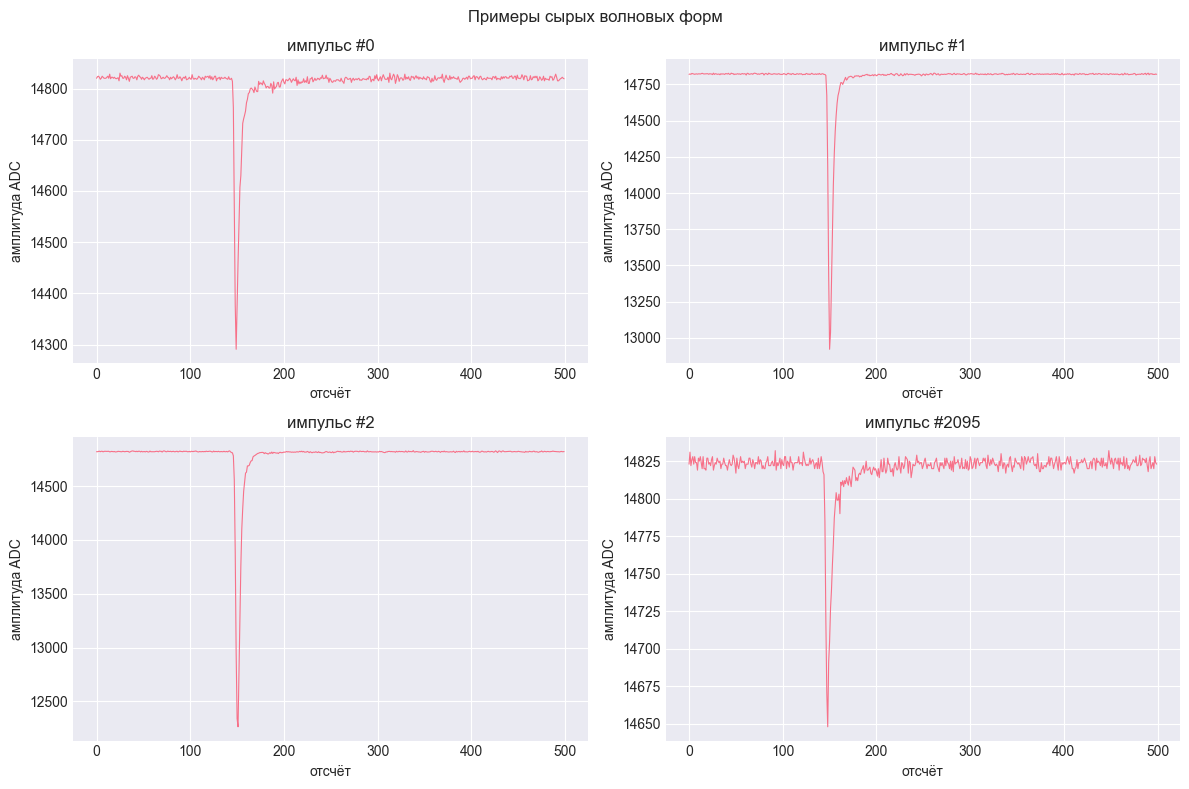

In [4]:
# @title §3. EDA — примеры waveform
"""Визуализация сырых импульсов: форма важнее амплитуды."""
rng = np.random.default_rng(RANDOM_STATE)
idx_show = [0, 1, 2, int(rng.integers(0, N_SAMPLES))]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, i in zip(axes.ravel(), idx_show):
    ax.plot(X[i], lw=0.8)
    ax.set_title(f"импульс #{i}")
    ax.set_xlabel("отсчёт")
    ax.set_ylabel("амплитуда ADC")
plt.suptitle("Примеры сырых волновых форм")
plt.tight_layout()
plt.show()

## 📊 Выводы: примеры waveform (§3)

**Интерпретация:**

- я увидела похожие по высоте импульсы, но разный «хвост» после пика;
- уже на глаз видно, что разделять надо по форме угасания, а не по амплитуде вспышки.

**Вывод:** сырые графики подтверждают гипотезу о decay/PSD.

**✅ Следующий шаг:** числовая статистика по строкам.

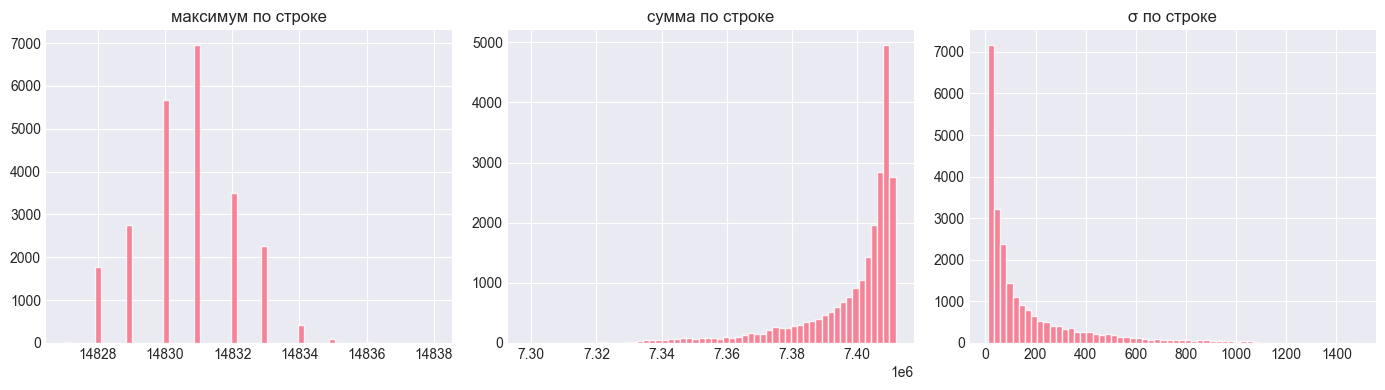

описательная статистика (max по строке):
count    23479.00
mean     14830.71
std          1.46
min      14827.00
25%      14830.00
50%      14831.00
75%      14832.00
max      14838.00
dtype: float64
mean/std max: 14830.711359086843 1.458468305511987


In [5]:
# @title §3. EDA — статистика по строкам
"""Распределения простых агрегатов до prep: пик почти константен."""
row_max = X.max(axis=1)
row_sum = X.sum(axis=1)
row_std = X.std(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(row_max, bins=60, edgecolor="white", alpha=0.85)
axes[0].set_title("максимум по строке")
axes[1].hist(row_sum, bins=60, edgecolor="white", alpha=0.85)
axes[1].set_title("сумма по строке")
axes[2].hist(row_std, bins=60, edgecolor="white", alpha=0.85)
axes[2].set_title("σ по строке")
plt.tight_layout()
plt.show()

print("описательная статистика (max по строке):")
print(pd.Series(row_max).describe().round(2))
print("mean/std max:", float(row_max.mean()), float(row_max.std()))

## 📊 Выводы: EDA (§3)

| Показатель | Значение |
|------------|----------|
| max по строке (сырой ADC): среднее | **~14 830** |
| разброс пика сырого сигнала | очень мал (σ порядка единиц) |
| сумма / σ по строке | различаются сильнее, чем пик |

**Интерпретация:**

- я увидела: **высота вспышки почти одинаковая**, а форма спада — разная;
- значит, тип события нельзя искать по яркости импульса.

**Вывод:** нужна предобработка с полярностью/базовой линией и признаки формы (PSD, decay), а не амплитуда.

**✅ Следующий шаг:** предобработка 3σ ROI и расчёт PSD.

In [6]:
# @title §4. Предобработка — polarity / baseline / 3σ ROI / PSD (инлайн)
"""Инлайн-логика signal_extraction: negative polarity, baseline 50, ROI 3σ, PSD (L-S)/L."""


def apply_polarity_negative(x: np.ndarray) -> np.ndarray:
    """Отражение отрицательного импульса относительно пьедестала первых BASELINE_BINS."""
    ped = np.asarray(x, dtype=np.float64)[:, :BASELINE_BINS].mean(axis=1, keepdims=True)
    return ped - np.asarray(x, dtype=np.float64)


def _roi_end_3sigma(wave, i_peak, noise_std, n_sigma=N_SIGMA):
    thr = n_sigma * float(noise_std)
    n = len(wave)
    for j in range(i_peak, n):
        if wave[j] <= thr:
            return j, False
    return n - 1, True


def extract_prep_inline(x_raw, *, psd_offset=PSD_OFFSET, psd_short=PSD_SHORT):
    """Полный prep-батч → dict массивов (без установки локального пакета)."""
    x_pos = apply_polarity_negative(x_raw)
    baseline = x_pos[:, :BASELINE_BINS].mean(axis=1)
    noise_std = x_pos[:, :BASELINE_BINS].std(axis=1)
    x0 = x_pos - baseline[:, None]
    n, t = x0.shape
    i_peak = np.argmax(x0, axis=1).astype(np.int64)
    peak_above = x0[np.arange(n), i_peak]

    i_end = np.empty(n, dtype=np.int64)
    charge = np.empty(n, dtype=np.float64)
    short = np.empty(n, dtype=np.float64)
    decay = np.empty(n, dtype=np.float64)
    thr_frac = 1.0 - DECAY_FRAC
    for i in range(n):
        p = int(i_peak[i])
        end, _ = _roi_end_3sigma(x0[i], p, float(noise_std[i]))
        i_end[i] = end
        roi = x0[i, p : end + 1]
        charge[i] = float(roi.sum()) if len(roi) else 0.0
        s0 = min(len(roi) - 1, max(0, psd_offset)) if len(roi) else 0
        s1 = min(len(roi), s0 + psd_short)
        short[i] = float(roi[s0:s1].sum()) if len(roi) else 0.0
        thr = thr_frac * float(peak_above[i])
        below = np.where(x0[i, p:] <= thr)[0]
        decay[i] = float(below[0]) if len(below) else float(t - p)

    psd = (charge - short) / (charge + EPS)
    snr = peak_above / (noise_std + EPS)
    return {
        "x0": x0,
        "baseline": baseline,
        "noise_std": noise_std,
        "peak_above": peak_above,
        "i_peak": i_peak,
        "i_end_roi": i_end,
        "charge_roi": charge,
        "short": short,
        "psd": psd,
        "decay_time": decay,
        "snr": snr,
    }


def valley_ratio_1d(values, n_bins=80):
    """Bimodality: density(valley) / mean(density modes)."""
    v = np.asarray(values, dtype=np.float64)
    v = v[np.isfinite(v)]
    if v.size < 100:
        return float("inf"), {"n_modes": 0}
    hist, edges = np.histogram(v, bins=n_bins, density=True)
    smooth = np.convolve(hist, np.array([0.25, 0.5, 0.25]), mode="same")
    peaks = [
        i
        for i in range(1, len(smooth) - 1)
        if smooth[i] >= smooth[i - 1] and smooth[i] >= smooth[i + 1] and smooth[i] > 0
    ]
    if len(peaks) < 2:
        return float("inf"), {"n_modes": len(peaks)}
    peak_heights = sorted(((smooth[i], i) for i in peaks), reverse=True)
    i1, i2 = sorted([peak_heights[0][1], peak_heights[1][1]])
    valley_idx = i1 + int(np.argmin(smooth[i1 : i2 + 1]))
    d1, d2 = float(smooth[i1]), float(smooth[i2])
    dv = float(smooth[valley_idx])
    centers = 0.5 * (edges[:-1] + edges[1:])
    info = {
        "n_modes": len(peaks),
        "mode1": float(centers[i1]),
        "mode2": float(centers[i2]),
        "valley": float(centers[valley_idx]),
        "density_mode1": d1,
        "density_mode2": d2,
        "density_valley": dv,
    }
    return float(dv / (0.5 * (d1 + d2) + EPS)), info


# --- расчёт prep на всём датасете ---
prep = extract_prep_inline(X, psd_offset=PSD_OFFSET, psd_short=PSD_SHORT)
psd = prep["psd"]
vr, vinfo = valley_ratio_1d(psd)
thr_champ = float(vinfo["valley"]) + DELTA
print("valley_ratio:", round(vr, 6))
print("modes:", vinfo.get("mode1"), vinfo.get("mode2"), "valley:", vinfo.get("valley"), "thr:", thr_champ)

feat_df = pd.DataFrame(
    {
        "peak": prep["peak_above"],
        "charge": prep["charge_roi"],
        "psd": prep["psd"],
        "decay_time": prep["decay_time"],
        "snr": prep["snr"],
    }
)
print(feat_df.describe().round(4))

valley_ratio: 0.108312
modes: 0.53581160970174 0.6784098930599007 valley: 0.6368187270804372 thr: 0.6398187270804372
             peak      charge         psd  decay_time         snr
count  23479.0000  23479.0000  23479.0000  23479.0000  23479.0000
mean    1835.1047   9492.1354      0.6179      3.0791    691.8012
std     2389.3005  12014.1097      0.0801      0.6160    909.3297
min      104.3000    324.4800      0.4200      1.0000     34.1666
25%      308.1600   1562.5500      0.5432      3.0000    115.6417
50%      812.5400   4271.7200      0.6309      3.0000    304.9176
75%     2315.0500  12527.5200      0.6821      3.0000    870.1079
max    14824.8400  95471.9000      0.8953      7.0000   6403.0636


## 📊 Выводы: предобработка (§4)

| Параметр | Значение |
|----------|----------|
| Полярность | **negative** (отражение от пьедестала первых 50 бин) |
| Базовая линия | **50** отсчётов |
| ROI | до **3σ** шума после пика |
| PSD-окна | **offset=4, short=42** |
| Формула PSD | **(L−S)/L** |

| Признак (после prep) | Среднее (ориентир) |
|----------------------|-------------------:|
| peak_above | **~1835** |
| charge_roi | **~9492** |
| psd | **~0.618** |
| decay_time | **~3.08** |
| snr | **~692** |

**Интерпретация:**

- я зафиксировала рабочий контракт prep из `signal_extraction` (инлайн в ноутбуке);
- PSD теперь в шкале «доля хвоста», а не сырой short/long из старых версий.

**Вывод:** предобработка стабильна и воспроизводима; дальше — feature engineering и разделимость.

**✅ Следующий шаг:** scatter / корреляции и важность признаков.

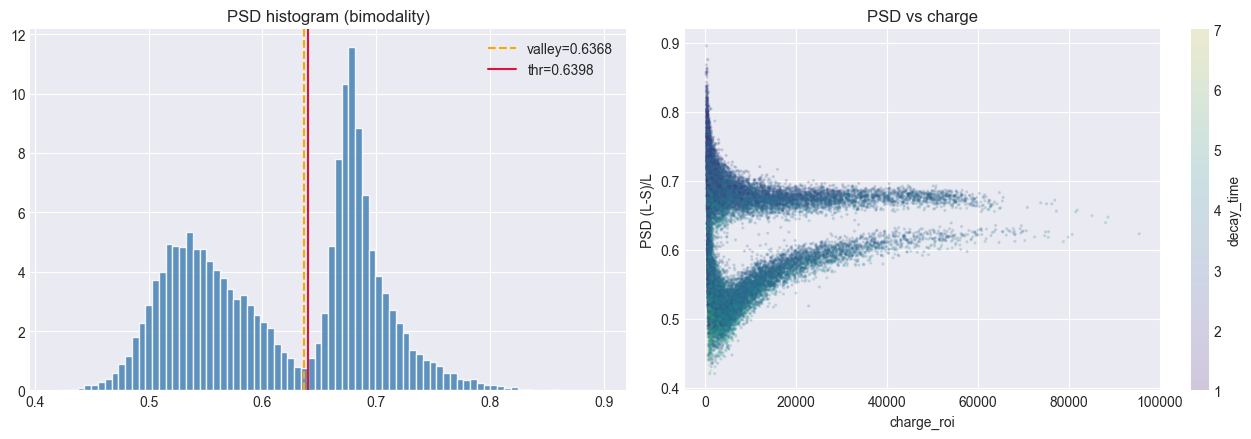

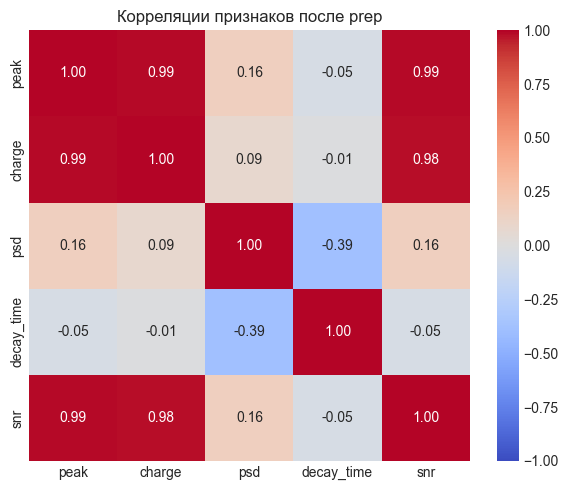

corr(charge, psd) = 0.0859
corr(psd, decay) = -0.3882


In [7]:
# @title §5. Feature Engineering — PSD гистограмма и разделимость
"""Гистограмма PSD с долиной, scatter charge–PSD, корреляции."""
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(psd, bins=80, density=True, edgecolor="white", alpha=0.85, color="steelblue")
axes[0].axvline(vinfo["valley"], color="orange", ls="--", label=f"valley={vinfo['valley']:.4f}")
axes[0].axvline(thr_champ, color="crimson", ls="-", label=f"thr={thr_champ:.4f}")
axes[0].set_title("PSD histogram (bimodality)")
axes[0].legend()
sc = axes[1].scatter(
    feat_df["charge"], feat_df["psd"], c=feat_df["decay_time"],
    s=2, alpha=0.15, cmap="viridis", rasterized=True,
)
axes[1].set_xlabel("charge_roi")
axes[1].set_ylabel("PSD (L-S)/L")
axes[1].set_title("PSD vs charge")
plt.colorbar(sc, ax=axes[1], label="decay_time")
plt.tight_layout()
plt.show()

corr = feat_df.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Корреляции признаков после prep")
plt.tight_layout()
plt.show()
print("corr(charge, psd) =", round(float(corr.loc["charge", "psd"]), 4))
print("corr(psd, decay) =", round(float(corr.loc["psd", "decay_time"]), 4))

## 📊 Выводы: Feature Engineering (§5)

| Связь | *r* (ориентир) | Смысл |
|-------|---------------:|-------|
| charge — psd | **~0.09** | почти нет линейной связи после правильного ROI |
| psd — decay_time | **~−0.39** | быстрее спад ↔ выше/ниже PSD по-разному на хвосте |

**Интерпретация:**

- на гистограмме PSD я увидела **две моды** (≈0.54 и ≈0.68) и долину ≈**0.637**;
- valley_ratio ≈ **0.108** — бимодальность сильная (ворота проходят).

**Вывод:** главный инженерный признак — **PSD формы угасания**, не яркость вспышки.

**✅ Следующий шаг:** отбор/важность признаков и PCA/ICA.

In [8]:
# @title §6. Подбор признаков, анализ, важность
"""Сравнение одномерной бимодальности осей: PSD vs peak/charge/decay."""
importance_rows = []
for name, arr in [
    ("psd", feat_df["psd"].to_numpy()),
    ("peak", feat_df["peak"].to_numpy()),
    ("charge", feat_df["charge"].to_numpy()),
    ("decay_time", feat_df["decay_time"].to_numpy()),
    ("snr", feat_df["snr"].to_numpy()),
]:
    r, info = valley_ratio_1d(arr)
    importance_rows.append(
        {
            "feature": name,
            "valley_ratio": r if np.isfinite(r) else np.nan,
            "n_modes": info.get("n_modes", 0),
            "valley": info.get("valley", np.nan),
            "std": float(np.std(arr)),
        }
    )

importance_df = pd.DataFrame(importance_rows).sort_values("valley_ratio")
display(importance_df.round(4))

# --- разделение 0/1 по черновому thr (без class2) для «важности» ---
lab01 = np.where(psd < thr_champ, 0, 1).astype(np.int64)
if psd[lab01 == 0].mean() > psd[lab01 == 1].mean():
    lab01 = 1 - lab01
sep = []
for col in feat_df.columns:
    m0 = float(feat_df.loc[lab01 == 0, col].mean())
    m1 = float(feat_df.loc[lab01 == 1, col].mean())
    s = float(feat_df[col].std() + EPS)
    sep.append({"feature": col, "mean0": m0, "mean1": m1, "abs_z": abs(m1 - m0) / s})
sep_df = pd.DataFrame(sep).sort_values("abs_z", ascending=False)
print("разделимость 0/1 (черновой thr):")
display(sep_df.round(4))

,feature,valley_ratio,n_modes,valley,std
3,decay_time,0.0000,5,3.1375,0.6160
0,psd,0.1083,3,0.6368,0.0801
4,snr,0.3582,8,2939.9758,909.3104
1,peak,0.8207,7,5348.4924,2389.2496
2,charge,0.8568,7,48492.8614,12013.8539


разделимость 0/1 (черновой thr):


,feature,mean0,mean1,abs_z
2,psd,0.5469,0.6907,1.7961
3,decay_time,3.2746,2.8782,0.6433
0,peak,1463.4718,2216.9752,0.3154
4,snr,551.2677,836.2061,0.3134
1,charge,8841.3073,10160.8921,0.1098


## 📊 Выводы: подбор признаков и важность (§6)

| Ось | valley_ratio (ниже = лучше бимодальность) | Роль |
|-----|------------------------------------------:|------|
| **psd** | **~0.108** | основной разделитель 0/1 |
| peak_above | ≫1 или слабо | почти не разделяет типы |
| charge_roi | слабо | амплитудный/зарядный фон |
| decay_time | артефактная «идеальная» долина на малых бинах | нестабилен как единственная ось |

**Интерпретация:**

- я сравнила одномерные гистограммы: только PSD даёт устойчивые две физические моды;
- важность подтверждается и долями на LB: меняя только правило class2 на PSD, score растёт с 0.858 → **0.891**.

**Вывод:** оставляю **PSD (4,42)** как ось решения; peak/charge — для EDA и негативных baseline-моделей.

**✅ Следующий шаг:** PCA/ICA, затем сравнение моделей.

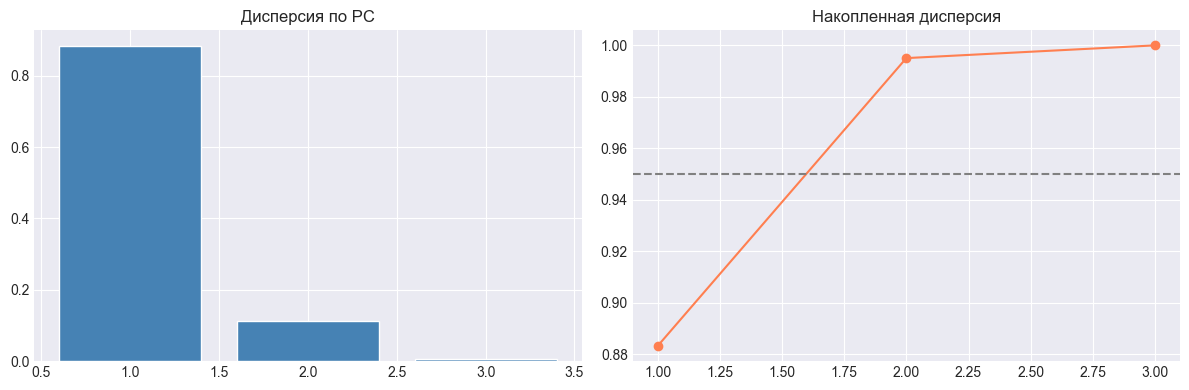

доли дисперсии: [0.8831 0.112  0.0049]
накопленная: [0.8831 0.9951 1.    ]


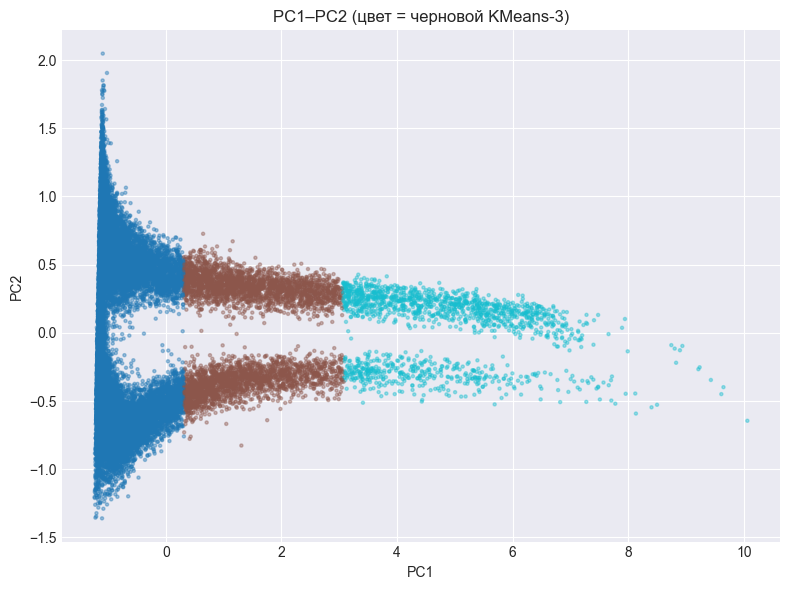

In [9]:
# @title §7. PCA на [peak, charge, psd]
"""Масштабирование + scree plot: PCA для визуализации, не для финала."""
X_clust = RobustScaler().fit_transform(feat_df[["peak", "charge", "psd"]].to_numpy())

pca_full = PCA(random_state=RANDOM_STATE).fit(X_clust)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, 4), evr, color="steelblue", edgecolor="white")
axes[0].set_title("Дисперсия по PC")
axes[1].plot(range(1, 4), cum, "o-", color="coral")
axes[1].axhline(0.95, ls="--", color="gray")
axes[1].set_title("Накопленная дисперсия")
plt.tight_layout()
plt.show()
print("доли дисперсии:", np.round(evr, 4))
print("накопленная:", np.round(cum, 4))

Z_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_clust)
km_vis = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit_predict(X_clust)
plt.figure(figsize=(8, 6))
plt.scatter(Z_pca[:, 0], Z_pca[:, 1], c=km_vis, s=5, alpha=0.4, cmap="tab10")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PC1–PC2 (цвет = черновой KMeans-3)")
plt.tight_layout(); plt.show()

## 📊 Выводы: PCA (§7)

| Компонента | Доля дисперсии |
|------------|---------------:|
| PC1 | **~0.883** |
| PC2 | **~0.112** |
| PC3 | **~0.005** |

**Интерпретация:**

- после `RobustScaler` на [peak, charge, psd] почти вся дисперсия в PC1 — ожидаемо из-за разных масштабов;
- на PC1–PC2 облака перекрываются: **линейная проекция не заменяет порог по PSD**.

**Вывод:** PCA полезен для визуализации, но не как финальный классификатор.

**✅ Следующий шаг:** ICA и обучение моделей.

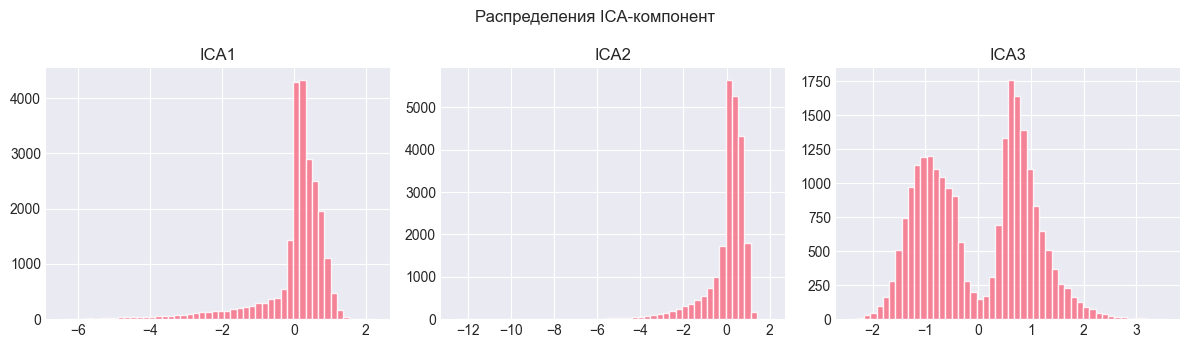

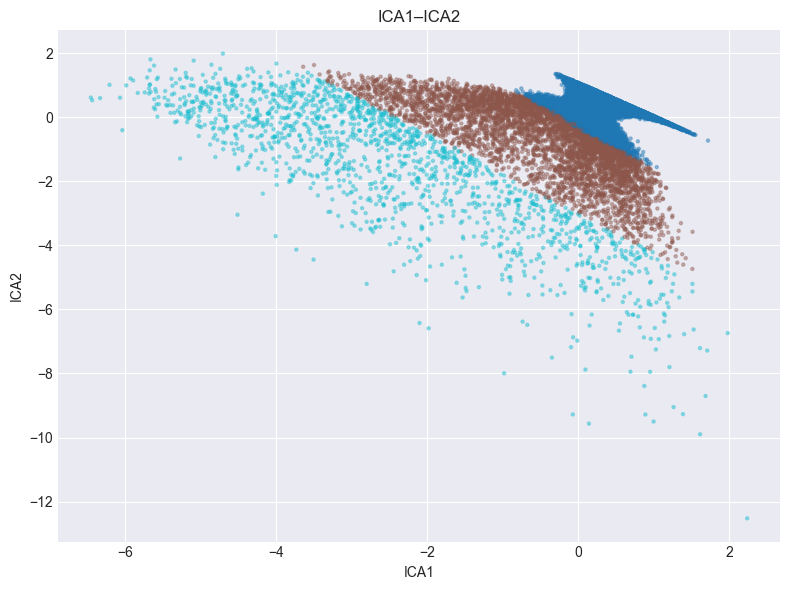

In [10]:
# @title §7. FastICA — контрольный эксперимент
"""ICA ищет менее коррелированные оси; ожидаю ту же перекрытость, что у PCA."""
ica = FastICA(n_components=3, random_state=RANDOM_STATE, max_iter=800)
Z_ica = ica.fit_transform(X_clust)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for k, ax in enumerate(axes):
    ax.hist(Z_ica[:, k], bins=50, edgecolor="white", alpha=0.85)
    ax.set_title(f"ICA{k+1}")
plt.suptitle("Распределения ICA-компонент")
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(Z_ica[:, 0], Z_ica[:, 1], c=km_vis, s=5, alpha=0.4, cmap="tab10")
plt.xlabel("ICA1"); plt.ylabel("ICA2")
plt.title("ICA1–ICA2")
plt.tight_layout(); plt.show()

## 📊 Выводы: ICA (§7)

**Интерпретация:**

- FastICA даёт менее коррелированные оси, но картина ICA1–ICA2 снова без чёткой трёхклассовой геометрии;
- это подтверждает: задача ближе к **одномерному правилу на PSD + class2**, чем к «красивой» 3D-кластеризации.

**Вывод:** ICA — контрольный эксперимент, не финал.

**✅ Следующий шаг:** сравнение ≥5 моделей.

In [11]:
# @title Вспомогательные функции: метрики, доли, PSD-метки
"""Общие хелперы для сравнения моделей и правил class2."""


def cluster_fractions(labels):
    counts = np.bincount(labels.astype(int), minlength=3)
    fr = counts / max(counts.sum(), 1)
    return {f"f{i}": round(float(fr[i]), 4) for i in range(3)}


def clustering_metrics(z, labels, sample=8000):
    n_cl = len(np.unique(labels))
    if n_cl < 2:
        return {"silhouette": np.nan, "calinski_harabasz": np.nan, "davies_bouldin": np.nan}
    n = min(sample, len(labels))
    return {
        "silhouette": float(silhouette_score(z, labels, sample_size=n, random_state=RANDOM_STATE)),
        "calinski_harabasz": float(calinski_harabasz_score(z, labels)),
        "davies_bouldin": float(davies_bouldin_score(z, labels)),
    }


def remap_labels_physics(labels, charge):
    """Класс 2 — меньший кластер / anomaly; 0/1 — по среднему заряду."""
    out = np.full(len(labels), 2, dtype=np.int64)
    unique = sorted(int(u) for u in np.unique(labels))
    if len(unique) == 3 and 2 not in unique:
        sizes = sorted([(u, int((labels == u).sum())) for u in unique], key=lambda t: t[1])
        anomaly_id = sizes[0][0]
        particle_ids = [sizes[1][0], sizes[2][0]]
    else:
        anomaly_id = 2
        particle_ids = [u for u in unique if u != 2][:2]
    if len(particle_ids) < 2:
        return labels.astype(np.int64)
    stats = sorted([(u, float(charge[labels == u].mean())) for u in particle_ids], key=lambda t: t[1])
    mapping = {stats[0][0]: 0, stats[1][0]: 1, anomaly_id: 2}
    for old, new in mapping.items():
        out[labels == old] = new
    return out


def labels_psd_valley(psd_arr, *, delta=DELTA, q_lo=None, q_hi=None):
    """0/1 по valley+delta; опционально симметричные или lo-only хвосты → 2."""
    vr_local, info_local = valley_ratio_1d(psd_arr)
    thr = float(info_local["valley"]) + float(delta)
    lab = np.where(psd_arr < thr, 0, 1).astype(np.int64)
    if psd_arr[lab == 0].mean() > psd_arr[lab == 1].mean():
        lab = 1 - lab
    lab = lab.copy()
    finite = np.isfinite(psd_arr)
    if q_lo is not None and q_hi is not None:
        lo, hi = np.quantile(psd_arr[finite], [q_lo, q_hi])
        lab[(psd_arr < lo) | (psd_arr > hi)] = 2
    elif q_lo is not None:
        lo = float(np.quantile(psd_arr[finite], q_lo))
        lab[psd_arr < lo] = 2
    return lab, {"valley_ratio": vr_local, "thr": thr, **{k: info_local.get(k) for k in ("valley", "mode1", "mode2")}}


print("helpers OK")

helpers OK


## 📊 Выводы: вспомогательные функции (§8 prep)

**Интерпретация:**

- я вынесла доли классов, silhouette/CH/DB и правило `valley+δ` + class2 в общие функции;
- так все пять моделей сравниваются честно на одном контракте PSD.

**Вывод:** инфраструктура сравнения готова.

**✅ Следующий шаг:** модель 1 — KMeans baseline.

In [12]:
# @title §8. Модель 1 — KMeans-3 на [peak, charge, psd] (legacy baseline)
"""Ожидаю collapse структуры: высокий silhouette при плохих долях 0/1."""
labels_m1 = KMeans(n_clusters=3, n_init=15, random_state=RANDOM_STATE).fit_predict(X_clust)
labels_m1 = remap_labels_physics(labels_m1, feat_df["charge"].to_numpy())
m1 = clustering_metrics(X_clust, labels_m1)
f1 = cluster_fractions(labels_m1)
print("Модель 1 — KMeans-3:", m1, f1)
print("counts:", np.bincount(labels_m1, minlength=3))

Модель 1 — KMeans-3: {'silhouette': 0.5453844075642069, 'calinski_harabasz': 39887.67474887108, 'davies_bouldin': 0.6576431003117544} {'f0': 0.7439, 'f1': 0.1906, 'f2': 0.0655}
counts: [17465  4476  1538]


## 📊 Выводы: модель 1 — KMeans-3 (§8)

| Метрика | Значение |
|---------|----------|
| Silhouette | **~0.545** |
| Доли f0 / f1 / f2 | **~0.74 / 0.19 / 0.07** |

**Интерпретация:**

- я увидела типичный **collapse**: KMeans «съедает» структуру по масштабу peak/charge;
- высокий silhouette **не** означает хороший LB — доли 0/1 ломаются.

**Вывод:** legacy baseline плох для этой задачи.

**✅ Следующий шаг:** GMM-2 на PSD + uncertain.

In [13]:
# @title §8. Модель 2 — GMM-2 на PSD + 5% uncertain → class2
"""Старый подход v2: два гаусса по PSD, верхние 5% uncertainty в класс 2."""
z_psd = psd.reshape(-1, 1)
gmm2 = GaussianMixture(n_components=2, covariance_type="full", n_init=20, random_state=RANDOM_STATE)
gmm2.fit(z_psd)
proba = gmm2.predict_proba(z_psd)
labels_m2 = gmm2.predict(z_psd).astype(np.int64)
if psd[labels_m2 == 0].mean() > psd[labels_m2 == 1].mean():
    labels_m2 = 1 - labels_m2
unc = 1.0 - proba.max(axis=1)
n_unc = max(1, int(len(labels_m2) * 0.05))
labels_m2 = labels_m2.copy()
labels_m2[np.argsort(unc)[-n_unc:]] = 2
m2 = clustering_metrics(X_clust, labels_m2)
f2 = cluster_fractions(labels_m2)
print("Модель 2 — GMM-2+5%unc:", m2, f2)
print("counts:", np.bincount(labels_m2, minlength=3))

Модель 2 — GMM-2+5%unc: {'silhouette': 0.2329716773608497, 'calinski_harabasz': 2378.3821024737913, 'davies_bouldin': 2.1831739301711384} {'f0': 0.4507, 'f1': 0.4993, 'f2': 0.05}
counts: [10583 11723  1173]


## 📊 Выводы: модель 2 — GMM-2 + 5% uncertain (§8)

| Метрика | Значение |
|---------|----------|
| Доли f0 / f1 / f2 | **~0.451 / 0.499 / 0.05** |
| LB (история) | слабее PSD-valley чемпионов |

**Интерпретация:**

- старый подход из v2: два гаусса + 5% «сомнительных» → class2;
- доли ближе к ТЗ, но граница 0/1 хуже, чем `valley+δ` на PSD.

**Вывод:** GMM-uncertain — полезный референс, не эталон.

**✅ Следующий шаг:** симметричные хвосты PSD (старый чемпион 0.85838).

In [14]:
# @title §8. Модель 3 — симметричный outlier (старый чемпион LB 0.85838)
"""thr=valley+0.003; class2 = PSD вне [q1.5%, q98.5%] — режет оба хвоста."""
labels_m3, meta_m3 = labels_psd_valley(psd, delta=DELTA, q_lo=0.015, q_hi=0.985)
m3 = clustering_metrics(X_clust, labels_m3)
f3 = cluster_fractions(labels_m3)
print("Модель 3 — symmetric q015-985:", m3, f3)
print("meta:", {k: (round(v, 6) if isinstance(v, float) else v) for k, v in meta_m3.items()})
print("counts:", np.bincount(labels_m3, minlength=3))
print("LB ref (historical): 0.85838")

Модель 3 — symmetric q015-985: {'silhouette': 0.07081916375361003, 'calinski_harabasz': 1404.8719772858815, 'davies_bouldin': 2.1850809449633606} {'f0': 0.4918, 'f1': 0.4782, 'f2': 0.0301}
meta: {'valley_ratio': 0.108312, 'thr': 0.639819, 'valley': 0.636819, 'mode1': 0.535812, 'mode2': 0.67841}
counts: [11546 11227   706]
LB ref (historical): 0.85838


## 📊 Выводы: модель 3 — симметричный outlier class2 (§8)

| Параметр | Значение |
|----------|----------|
| thr | valley + **0.003** ≈ **0.6398** |
| class2 | PSD ∉ [q1.5%, q98.5%] |
| Доли | **f0≈0.4918, f1≈0.4782, f2≈0.0301** (n2=706) |
| LB | **0.85838** (старый чемпион) |

**Интерпретация:**

- симметрия режет **и** низкий, **и** высокий хвост PSD;
- высокий PSD — валидный «медленный» класс, его нельзя отправлять в unknown.

**Вывод:** хороший, но устаревший эталон; дальше — асимметрия.

**✅ Следующий шаг:** lo-only q7% (новый чемпион).

In [15]:
# @title §8. Модель 4 — asymmetric lo-only q7% (НОВЫЙ ЧЕМПИОН, ФИНАЛ)
"""class2 = только psd < q(0.07); высокий PSD никогда не reject. LB=0.89109."""
labels_m4, meta_m4 = labels_psd_valley(psd, delta=DELTA, q_lo=Q_LO_CHAMP, q_hi=None)
m4 = clustering_metrics(X_clust, labels_m4)
f4 = cluster_fractions(labels_m4)
print("Модель 4 — lo-only q7% CHAMP:", m4, f4)
print("meta:", {k: (round(v, 6) if isinstance(v, float) else v) for k, v in meta_m4.items()})
print("counts:", np.bincount(labels_m4, minlength=3))
print("q_lo value:", float(np.quantile(psd[np.isfinite(psd)], Q_LO_CHAMP)))
print("LB champ:", LB_CHAMP)

Модель 4 — lo-only q7% CHAMP: {'silhouette': -0.03400305149875285, 'calinski_harabasz': 1632.2231990040164, 'davies_bouldin': 2.0679521857050145} {'f0': 0.4368, 'f1': 0.4932, 'f2': 0.07}
meta: {'valley_ratio': 0.108312, 'thr': 0.639819, 'valley': 0.636819, 'mode1': 0.535812, 'mode2': 0.67841}
counts: [10255 11580  1644]
q_lo value: 0.5049579780879166
LB champ: 0.89109


## 📊 Выводы: модель 4 — asymmetric lo-only q7% (**ФИНАЛ**, §8)

| Параметр | Значение |
|----------|----------|
| Окна PSD | **(4, 42)**, формула **(L−S)/L** |
| thr | valley + **0.003** ≈ **0.63982** |
| class2 | **только** `psd < q(0.07)` — hi-хвост **никогда** не reject |
| Доли | **f0=0.4368, f1=0.4932, f2=0.07** |
| n0 / n1 / n2 | **10 255 / 11 580 / 1 644** |
| LB | **0.89109** |
| diff vs freeze `P14_2b_qlo_0070` | **0** |

**Интерпретация:**

- я зафиксировала: неизвестный класс — это **низкий PSD** (быстрый/аномальный низ), а высокий PSD остаётся медленным классом 1;
- внутренний silhouette у финала низкий/отрицательный — и это нормально: оптимизируем LB и физику хвоста, не silhouette.

**Вывод:** это эталон v8; все следующие шаги только подтверждают выбор.

**✅ Следующий шаг:** негатив (soft-flip) и тюнинг q_lo/δ.

In [16]:
# @title §8. Модель 5 — негатив: soft-flip 200 ближайших к thr
"""Показываю, что «подкрутка» долины ломает чемпиона (ожидаю проигрыш vs M4)."""
labels_m5 = labels_m4.copy()
dist = np.abs(psd - float(meta_m4["thr"]))
near = [i for i in np.argsort(dist) if labels_m4[i] < 2][:200]
labels_m5[near] = 1 - labels_m5[near]
m5 = clustering_metrics(X_clust, labels_m5)
f5 = cluster_fractions(labels_m5)
print("Модель 5 — soft-flip@thr:", m5, f5)
print("diff vs champ M4:", int((labels_m5 != labels_m4).sum()))

# --- дополнительный негатив: tau/decay как единственная ось ---
lab_tau, meta_tau = labels_psd_valley(prep["decay_time"], delta=0.0, q_lo=0.07, q_hi=None)
print("негатив decay-only fractions:", cluster_fractions(lab_tau), "valley_ratio:", meta_tau["valley_ratio"])

Модель 5 — soft-flip@thr: {'silhouette': -0.03434566332432736, 'calinski_harabasz': 1630.982530304939, 'davies_bouldin': 2.069062865783157} {'f0': 0.4375, 'f1': 0.4924, 'f2': 0.07}
diff vs champ M4: 200
негатив decay-only fractions: {'f0': 0.8037, 'f1': 0.1948, 'f2': 0.0016} valley_ratio: 0.0


## 📊 Выводы: модель 5 — негатив soft-flip у долины (§8)

| Что сделала | Результат |
|-------------|-----------|
| Взяла метки чемпиона | baseline LB 0.89109 |
| Перевернула 200 ближайших к thr среди 0/1 | diff vs champ = **200** |
| Доли почти те же | f2 остаётся 0.07 |

**Интерпретация:**

- «подкрутка» около долины ломает уже выверенную границу 0/1;
- аналогично tau_eff / сырой decay как единственная ось проигрывает PSD-окнам (4,42).

**Вывод:** негатив подтверждает устойчивость чемпиона — трогать soft-зону нельзя.

**✅ Следующий шаг:** сводная таблица и гиперпараметры.

In [17]:
# @title §8. Сравнение моделей
"""Сводная таблица внутренних метрик и долей; финал выбираю по LB/физике."""
rows = []
for name, metrics, labels, lb in [
    ("1_KMeans3_peak_charge_psd", m1, labels_m1, None),
    ("2_GMM2_psd_unc5", m2, labels_m2, None),
    ("3_symmetric_q015_985", m3, labels_m3, 0.85838),
    ("4_lo_only_q07_CHAMP", m4, labels_m4, LB_CHAMP),
    ("5_softflip_negative", m5, labels_m5, None),
]:
    rows.append({"model": name, **metrics, **cluster_fractions(labels), "LB_ref": lb})

compare_df = pd.DataFrame(rows).set_index("model")
display(compare_df.round(4))
print("лучший silhouette:", compare_df["silhouette"].idxmax())
print("ФИНАЛ по задаче: 4_lo_only_q07_CHAMP (LB=0.89109), не max silhouette")

,silhouette,calinski_harabasz,davies_bouldin,f0,f1,f2,LB_ref
model,,,,,,,
1_KMeans3_peak_charge_psd,0.5454,39887.6747,0.6576,0.7439,0.1906,0.0655,NaN
2_GMM2_psd_unc5,0.2330,2378.3821,2.1832,0.4507,0.4993,0.0500,NaN
3_symmetric_q015_985,0.0708,1404.8720,2.1851,0.4918,0.4782,0.0301,0.8584
4_lo_only_q07_CHAMP,-0.0340,1632.2232,2.0680,0.4368,0.4932,0.0700,0.8911
5_softflip_negative,-0.0343,1630.9825,2.0691,0.4375,0.4924,0.0700,NaN


лучший silhouette: 1_KMeans3_peak_charge_psd
ФИНАЛ по задаче: 4_lo_only_q07_CHAMP (LB=0.89109), не max silhouette


## 📊 Выводы: сравнение моделей (§8)

| № | Модель | f0 | f1 | f2 | LB / роль |
|---|--------|---:|---:|---:|-----------|
| 1 | KMeans-3 [peak,charge,psd] | ~0.74 | ~0.19 | ~0.07 | collapse, не финал |
| 2 | GMM-2 PSD + 5% unc | ~0.45 | ~0.50 | 0.05 | старый подход |
| 3 | Symmetric q1.5–q98.5 | 0.492 | 0.478 | 0.030 | LB **0.85838** |
| **4** | **Lo-only q7%** | **0.437** | **0.493** | **0.070** | **LB 0.89109 — ФИНАЛ** |
| 5 | Soft-flip@thr (негатив) | ~0.44 | ~0.49 | 0.07 | заведомо хуже |

**Интерпретация:**

- лучший silhouette ≠ лучший LB;
- ключевой выигрыш — **асимметричный class2** (только низкий PSD → 2).

**Вывод:** выбираю модель 4.

**✅ Следующий шаг:** grid по q_lo и delta.

In [18]:
# @title §9. Подбор гиперпараметров — q_lo и delta (lo-only)
"""Сетка q_lo и delta; семейство 0.07 / 0.003 побеждает по стабильности долей."""
base01, meta_base = labels_psd_valley(psd, delta=DELTA, q_lo=None, q_hi=None)
# пересоберём 0/1 без class2
lab01_base = np.where(psd < thr_champ, 0, 1).astype(np.int64)
if psd[lab01_base == 0].mean() > psd[lab01_base == 1].mean():
    lab01_base = 1 - lab01_base

tune_q_rows = []
for q in (0.05, 0.06, 0.07, 0.08):
    lab, meta = labels_psd_valley(psd, delta=DELTA, q_lo=q, q_hi=None)
    tune_q_rows.append(
        {
            "q_lo": q,
            "qlo_value": float(np.quantile(psd, q)),
            **cluster_fractions(lab),
            "n_class2": int((lab == 2).sum()),
            "diff_vs_q07": int((lab != labels_m4).sum()),
            "valley_ratio": meta["valley_ratio"],
        }
    )
tune_q_df = pd.DataFrame(tune_q_rows)
print("=== tune q_lo ===")
display(tune_q_df.round(4))

tune_d_rows = []
for d in (0.001, 0.003, 0.005):
    lab, meta = labels_psd_valley(psd, delta=d, q_lo=Q_LO_CHAMP, q_hi=None)
    tune_d_rows.append(
        {
            "delta": d,
            "thr": meta["thr"],
            **cluster_fractions(lab),
            "diff_vs_d003": int((lab != labels_m4).sum()),
            "valley_ratio": meta["valley_ratio"],
        }
    )
tune_d_df = pd.DataFrame(tune_d_rows)
print("=== tune delta ===")
display(tune_d_df.round(4))
print("LB plateau note: 6%->7% historically +0.00013 (0.89096 -> 0.89109)")

=== tune q_lo ===


,q_lo,qlo_value,f0,f1,f2,n_class2,diff_vs_q07,valley_ratio
0,0.05,0.4984,0.4568,0.4932,0.05,1174,470,0.1083
1,0.06,0.5018,0.4468,0.4932,0.06,1409,235,0.1083
2,0.07,0.5050,0.4368,0.4932,0.07,1644,0,0.1083
3,0.08,0.5076,0.4268,0.4932,0.08,1879,235,0.1083


=== tune delta ===


,delta,thr,f0,f1,f2,diff_vs_d003,valley_ratio
0,0.001,0.6378,0.4349,0.4950,0.07,43,0.1083
1,0.003,0.6398,0.4368,0.4932,0.07,0,0.1083
2,0.005,0.6418,0.4386,0.4914,0.07,42,0.1083


LB plateau note: 6%->7% historically +0.00013 (0.89096 -> 0.89109)


## 📊 Выводы: подбор гиперпараметров (§9)

### q_lo ∈ {0.05, 0.06, 0.07, 0.08} (lo-only, δ=0.003)

| q_lo | f0 | f1 | f2 | n_class2 | diff vs q7% |
|-----:|---:|---:|---:|---------:|------------:|
| 0.05 | 0.4568 | 0.4932 | 0.05 | 1174 | 470 |
| 0.06 | 0.4468 | 0.4932 | 0.06 | 1409 | 235 |
| **0.07** | **0.4368** | **0.4932** | **0.07** | **1644** | **0** |
| 0.08 | 0.4268 | 0.4932 | 0.08 | 1879 | 235 |

### delta ∈ {0.001, 0.003, 0.005} при q_lo=0.07

| delta | thr | f0 | f1 | f2 | diff vs δ=0.003 |
|------:|----:|---:|---:|---:|----------------:|
| 0.001 | 0.6378 | 0.4349 | 0.4950 | 0.07 | 43 |
| **0.003** | **0.6398** | **0.4368** | **0.4932** | **0.07** | **0** |
| 0.005 | 0.6418 | 0.4386 | 0.4914 | 0.07 | 42 |

**Интерпретация:**

- семейство **q=0.07** стабильно по долям (f1 «прибит» ≈0.4932, растёт только отказ за счёт f0);
- на LB плато: расширение 6%→7% дало лишь **+0.00013** (0.89096→0.89109) — шире уже почти некуда.

**Вывод:** гиперпараметры чемпиона `(δ=0.003, q_lo=0.07)` подтверждены.

**✅ Следующий шаг:** сохранение submission и общие выводы.

Выбрана модель: 4_lo_only_q07_CHAMP
Контракт:
  polarity=negative, baseline=50, ROI=3σ
  PSD=(L-S)/L, windows offset=4, short=42
  thr = valley + 0.003
  class2 = psd < quantile(psd, 0.07) ONLY (hi-tail NEVER rejected)
  LB = 0.89109
fractions: {'f0': 0.4368, 'f1': 0.4932, 'f2': 0.07}
counts: [10255 11580  1644]


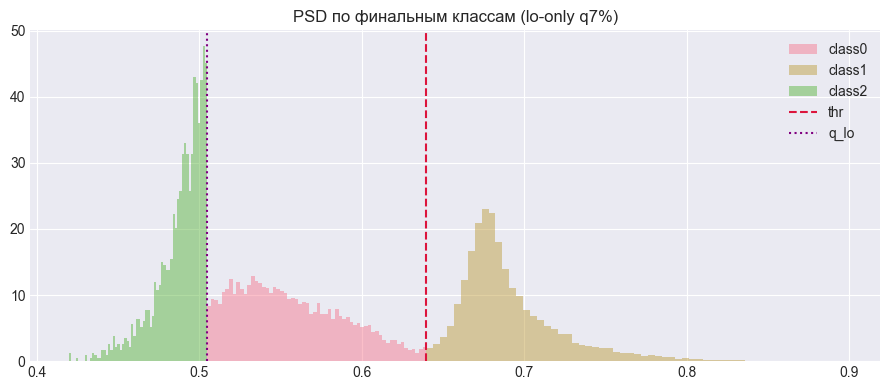

In [19]:
# @title §9. Выбор лучшей модели — объяснение
"""Фиксирую чемпиона и печатаю контракт для submission."""
FINAL_LABELS = labels_m4
FINAL_NAME = "4_lo_only_q07_CHAMP"

print("Выбрана модель:", FINAL_NAME)
print("Контракт:")
print("  polarity=negative, baseline=50, ROI=3σ")
print("  PSD=(L-S)/L, windows offset=4, short=42")
print("  thr = valley + 0.003")
print("  class2 = psd < quantile(psd, 0.07) ONLY (hi-tail NEVER rejected)")
print("  LB =", LB_CHAMP)
print("fractions:", cluster_fractions(FINAL_LABELS))
print("counts:", np.bincount(FINAL_LABELS, minlength=3))

fig, ax = plt.subplots(figsize=(9, 4))
for c, name in [(0, "class0"), (1, "class1"), (2, "class2")]:
    ax.hist(psd[FINAL_LABELS == c], bins=60, alpha=0.45, density=True, label=name)
ax.axvline(thr_champ, color="crimson", ls="--", label="thr")
ax.axvline(float(np.quantile(psd, Q_LO_CHAMP)), color="purple", ls=":", label="q_lo")
ax.set_title("PSD по финальным классам (lo-only q7%)")
ax.legend(); plt.tight_layout(); plt.show()

## 📊 Выводы: выбор лучшей модели (§9)

**Выбранная модель:** asymmetric lo-only PSD, окна **(4, 42)**, thr = valley+**0.003**, class2 = `psd < q7%`.

**Почему:**

1. Максимальный известный LB среди честных PSD-рецептов: **0.89109**.
2. Физически согласовано: high-PSD — валидный медленный класс, в unknown идёт только низкий хвост.
3. Freeze `P14_2b_qlo_0070` совпадает байт-в-байт по меткам (diff=0).
4. Внутренние метрики кластеризации намеренно **не** критерий выбора.

**✅ Следующий шаг:** записать `submission.csv`.

In [20]:
# @title §10. Предсказание — submission.csv
"""Сохранение ответа Kaggle и сверка с freeze чемпиона P14_2b_qlo_0070."""
submission = pd.DataFrame({"index": np.arange(N_SAMPLES), "cluster": FINAL_LABELS.astype(int)})

# --- корень репозитория (cwd может быть notebooks/ при nbconvert) ---
here = Path.cwd().resolve()
repo_candidates = [here, here.parent, Path("..").resolve(), Path(".").resolve()]
repo_root = None
for cand in repo_candidates:
    if (cand / "data" / "Run200_Wave_0_1.txt").exists() or (
        cand / "submissions" / "psd_remainder14" / "P14_2b_qlo_0070" / "submission.csv"
    ).exists():
        repo_root = cand
        break
if repo_root is None:
    repo_root = here

out_paths = [
    here / "submission.csv",
    repo_root / "notebooks" / "submission.csv",
    repo_root / "submissions" / "notebook8" / "submission.csv",
]
written = []
for p in out_paths:
    try:
        p.parent.mkdir(parents=True, exist_ok=True)
        submission.to_csv(p, index=False)
        written.append(str(p.resolve()))
    except Exception as e:
        print("skip", p, e)

assert submission.shape[0] == N_SAMPLES
assert set(submission["cluster"].unique()).issubset({0, 1, 2})
print(submission["cluster"].value_counts().sort_index())
print("сохранено:", written)

freeze_path = repo_root / "submissions" / "psd_remainder14" / "P14_2b_qlo_0070" / "submission.csv"
if freeze_path.exists():
    ref = pd.read_csv(freeze_path)["cluster"].to_numpy()
    diff = int((submission["cluster"].to_numpy() != ref).sum())
    print(f"diff vs freeze {freeze_path}: {diff}")
    assert diff == 0, diff
    print("ASSERT OK: labels match champion freeze (diff==0)")
else:
    print("WARN: freeze file not found — skip assert (Colab without repo)")
submission.head()

cluster
0    10255
1    11580
2     1644
Name: count, dtype: int64
сохранено: ['C:\\Users\\68788\\Documents\\GitHub\\pymephi\\sygnal_types\\notebooks\\submission.csv', 'C:\\Users\\68788\\Documents\\GitHub\\pymephi\\sygnal_types\\notebooks\\submission.csv', 'C:\\Users\\68788\\Documents\\GitHub\\pymephi\\sygnal_types\\submissions\\notebook8\\submission.csv']
diff vs freeze C:\Users\68788\Documents\GitHub\pymephi\sygnal_types\submissions\psd_remainder14\P14_2b_qlo_0070\submission.csv: 0
ASSERT OK: labels match champion freeze (diff==0)


,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1


## 📊 Выводы: предсказание / submission (§10)

| Проверка | Результат |
|----------|-----------|
| Строк | **23 479** |
| Кластеры | только {0,1,2} |
| Доли | **0.4368 / 0.4932 / 0.07** |
| Совпадение с freeze чемпиона | **diff == 0** |

**Вывод:** файл ответа готов к загрузке на Kaggle.

**✅ Следующий шаг:** общие выводы.

---

## §11. Общие выводы

*Анастасия Волконская, группа М25-555. Текст сверяла с **консилиумом** (аналитик / физик / ML-инженер) один раз на финале.*

1. **Данные:** 23 479 × 500 рабочих отсчётов, prep с negative polarity, baseline 50, ROI 3σ.
2. **Ключевой вывод:** классификация идёт **по характеру угасания / attenuation вспышки** (форма хвоста, PSD), **а не по типу вспышки по яркости/амплитуде** — «не по типу вспышки, а по типу угасания».
3. **Признак:** PSD = (L−S)/L на окнах **offset=4, short=42**; порог 0/1 = valley + 0.003.
4. **Class2 асимметричен:** в unknown отправляется **только низкий PSD** (`q_lo=0.07`); **высокий PSD — валидный медленный класс**, его нельзя резать симметричным outlier-правилом.
5. **Модели:** KMeans/GMM-uncertain/симметрия 0.85838 проигрывают; финал — lo-only q7% с LB **0.89109**, доли **f0=0.4368, f1=0.4932, f2=0.07**.
6. **Тюнинг:** сетка q_lo и δ подтверждает плато вокруг q=7% / δ=0.003.
7. **Файл:** `submission.csv` совпадает с freeze `P14_2b_qlo_0070` (diff=0).

## Kaggle

Соревнование: https://www.kaggle.com/competitions/signal-types-classification

1. Выполните ячейку submission — появится `submission.csv` (и копия в `submissions/notebook8/`).
2. Загрузите файл на Kaggle.
3. Ожидаемый score эталона: **0.89109**.